<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustering_ModernBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
#### **Topic modelling by embedding vector space with `ModerBERT`**

In this notebook we used `ModernBERT-base` model and Turftopics library to develop a topic modelling and clustering code.

**ModernBERT** is a modernized bidirectional encoder-only Transformer model (BERT-style) pre-trained on 2 trillion tokens of English and code data with a native context length of up to 8,192 tokens. ModernBERT leverages recent architectural improvements such as:

 - Rotary Positional Embeddings (RoPE) for long-context support.
 - Local-Global Alternating Attention for efficiency on long inputs.
 - Unpadding and Flash Attention for efficient inference.

It is available in the following sizes:
 - ModernBERT-base - 22 layers, 149 million parameters
 - ModernBERT-large - 28 layers, 395 million parameters

ModernBERT's **embedding dimensions** vary depending on the specific model variant, with common sizes including 768 for the modernbert-embed-base model, 1024 for modernbert-embed-large



**Turftopic** is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

**Sources:**

turftopics:

* https://x-tabdeveloping.github.io/turftopic/

ModernBERT:
* https://huggingface.co/blog/modernbert
* https://huggingface.co/docs/transformers/en/model_doc/modernbert
* https://huggingface.co/answerdotai/ModernBERT-base
* https://huggingface.co/answerdotai/ModernBERT-large

## **Step 1: Install Packages and Import Required Libraries**

This step focuses on preparing the environment for topic modeling and data analysis. Here's what you did:

1. **Package Installation**:

   * Installed the `turftopic` package with optional dependencies like `umap-learn` and `datamapplot`, which are essential for dimensionality reduction and visualization.
   * Installed the `topicwizard` package. It is a pretty and opinionated Python library for topic model visualization built on Dash and Plotly.

2. **Library Imports**:

   * Imported standard data processing and visualization libraries: `numpy`, `pandas`, `seaborn`, `matplotlib`, and `torch`.
   * Imported libraries for topic modeling using pre-trained transformer models:

     * `SentenceTransformer` from `sentence_transformers` for sentence embeddings.
     * `AutoTokenizer` and `AutoModel` from `transformers` for tokenizing and encoding text data.
     * `Top2Vec` and `BERTopic` from `turftopic` for topic clustering.
   * Imported clustering and visualization tools:

     * `linkage` and `dendrogram` from `scipy.cluster.hierarchy` for hierarchical clustering visualization.
     * `cosine_distances` from `sklearn.metrics.pairwise` for distance calculations.
   * Imported evaluation metrics:

     * `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score` from `sklearn.metrics` to assess clustering quality.

This step ensures that all necessary components are in place to proceed with topic modeling and analysis.

---

In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

#!pip install datasets plotly turftopic[umap-learn, datamapplot]
!pip install topic-wizard

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import BERTopic
from turftopic import Top2Vec
from tqdm import tqdm

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

# Required libraries for dendrogram and visualisation
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram

# Google drive library
from google.colab import drive
drive.mount('/content/drive')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


## **Step 2: Load and Read from the Original Dataset**

This step is about acquiring and inspecting the dataset for further analysis. Here's what was done:

1. **Dataset Source**:

   * A sample dataset of 10,000 PubMed abstracts was loaded, including metadata such as titles and publication years. The dataset was sourced from a Graph Database and accessed via a file path.

2. **File Loading**:

   * Used `pandas.read_csv` to load the dataset from Google Drive:


3. **Initial Exploration**:

   * Printed the dataset’s shape and content to understand its structure.
   * Isolated the `abstract` column, dropping any rows with missing data and resetting the index:
   * Displayed a few samples from the cleaned dataset to verify correct loading.
   * Called `dataset.info()` to summarize the dataset structure, including column names, data types, and missing values.

This step successfully loads and prepares the textual data (abstracts) for embedding and topic modeling in later steps.

---

In [ ]:
### --- Option 1: Google Drive --- ###
# Read and Load dataset
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

# ### --- Option 2: Google Clab (Any Other online platform) --- ###
# # Read and Load dataset from root
# dataset = pd.read_csv('sample_PubMedDataAbstracts.csv')

# # Show the datasets
# ### Abstract Embeddings Sample Dataset
# print('Node Content:', dataset.shape)
# print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [ ]:
# Show basic info od dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       10000 non-null  object
 2   abstract    10000 non-null  object
 3   year        10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [ ]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].tolist()

# Display a few samples to verify
abstracts[:5]

['Background Niemann-Pick disease type C (NPC) is a lysosomal storage disorder with severe prognosis. Disease-specific therapy is crucial to prevent disease progression; however, diagnosing NPC is quite difficult because of remarkably variable clinical presentations. The NPC Suspicion Index (NPC-SI) was developed to overcome this problem. Identifying preclinical cases is important for prevention and therapy. Here, we report three newly diagnosed NPC cases, one typical juvenile-onset case and the cases of two sisters with symptoms neurologically/psychiatrically indistinguishable from dystonia and schizophrenia, respectively. Case presentation In Case 1, a 25-year-old man presented with a 14-year history of intellectual disability, clumsiness, spastic ataxia, dysphagia, and frequent falls. Neurological examination revealed vertical supranuclear gaze palsy and involuntary movements. Ultrasonography revealed mild splenomegaly, and filipin staining of skin fibroblasts was positive with a va

## **Step 3: Extract Embeddings using ModerBERT**
---

This step is designed to obtain vector embeddings of text (e.g., abstracts) using the **ModernBERT-base** model from Hugging Face. The code provides three different approaches, though only the pre-computed embeddings are used in practice:

1. **Setup**

   * Loads the **ModernBERT tokenizer and model** (`answerdotai/ModernBERT-base`) from Hugging Face.

2. **GPU-based embedding extraction (commented out)**

   * Moves the model to GPU (if available).
   * Defines a function `get_embeddings()` that tokenizes each text, passes it through the model, and extracts the **\[CLS] token embedding**.
   * Embeddings are collected and stored in a list.

3. **CPU-based embedding extraction (commented out)**

   * Similar to the GPU version, but computations stay on the CPU.
   * Uses `tqdm` to show progress when embedding many texts.
   * Results could be saved into a CSV file (`abstract_embeddings.csv`).

4. **Using Pre-computed embeddings (active code)**

   * To save computational resources, embeddings are **loaded from a CSV file** that was previously generated using ModernBERT.
   * `np.loadtxt()` reads the embeddings into memory.
   * The code checks the number of embeddings and their dimensionality.

---

In [ ]:
# Load ModernBERT tokenizer and model from Hugging Face
MODEL_NAME = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

In [ ]:
### --- Option 1: Move model to GPU if available --- ###
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)

# # Function to get embeddings for a list of texts using GPU
# def get_embeddings(texts, tokenizer, model):
#     model.eval()
#     device = next(model.parameters()).device  # ensures model and inputs are on same device
#     embeddings = []

#     with torch.no_grad():
#         for text in texts:
#             inputs = tokenizer(text, return_tensors="pt", truncation=False, padding=True)
#             inputs = {k: v.to(device) for k, v in inputs.items()}  # move inputs to GPU
#             outputs = model(**inputs)
#             cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()  # back to CPU
#             embeddings.append(cls_embedding)

#     return embeddings

### --- Option 1: Use default cpu to run the model --- ###

# # Function to get embeddings for a list of texts using CPU
# def get_embeddings(texts, tokenizer, model):
#     model.eval()
#     embeddings = []

#     with torch.no_grad():
#         for text in texts:
#             inputs = tokenizer(text, return_tensors="pt", truncation=False, padding=True)
#             outputs = model(**inputs)
#             # Use [CLS] token embedding (first token)
#             cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
#             embeddings.append(cls_embedding)

#     return embeddings

In [ ]:
# # Wrap the texts with tqdm for progress visualization
# abstracts = abstracts
# abstracts_with_progress = tqdm(abstracts, desc="Embedding abstracts")

# # Call the function with tqdm-wrapped list
# abstract_embeddings = get_embeddings(abstracts_with_progress, tokenizer, model)

In [ ]:
# # save abstract_embeddings into csv file
# np.savetxt("abstract_embeddings.csv", abstract_embeddings, delimiter=",")

### Use Pre-embeddings as csv file

In [ ]:
# Use pre-embeddings csv file
pre_embeddings = np.loadtxt("/content/drive/MyDrive/Internship/Datasets/SampleDataset/Sample_Dataset_Abstract_Embeddings.csv", delimiter=",")

# Get embeddings from csv file
abstract_embeddings = pre_embeddings
abstract_embeddings

array([[ 0.30497697, -0.20869878, -0.18874036, ..., -1.1213119 ,
         0.63652396, -0.54932749],
       [ 0.46238339, -0.65232009,  0.29970372, ..., -1.25551248,
         1.12826502, -0.34438741],
       [-0.23266809, -0.51089746, -0.0102424 , ..., -1.5995301 ,
         0.76797158, -0.77237844],
       ...,
       [-0.27163851, -0.38257405, -0.21645126, ..., -1.50330627,
         0.93543106, -0.24376546],
       [ 0.09230014, -0.67846876, -0.27810726, ..., -1.78912866,
         0.487746  , -0.64731061],
       [-0.08118434, -0.49155283, -0.31141263, ..., -1.76977527,
         0.94671571, -0.40294534]])

In [ ]:
# Show shape of the first embedding
print(f"Length: {len(abstract_embeddings)}", "\n")
print(f"Dimention of rows: {abstract_embeddings[0].shape}", "\n")

# Show embeddings matrix and Check the dimention of each eambeding
embeddings = np.array(abstract_embeddings)
print(embeddings)

Length: 10000 

Dimention of rows: (768,) 

[[ 0.30497697 -0.20869878 -0.18874036 ... -1.1213119   0.63652396
  -0.54932749]
 [ 0.46238339 -0.65232009  0.29970372 ... -1.25551248  1.12826502
  -0.34438741]
 [-0.23266809 -0.51089746 -0.0102424  ... -1.5995301   0.76797158
  -0.77237844]
 ...
 [-0.27163851 -0.38257405 -0.21645126 ... -1.50330627  0.93543106
  -0.24376546]
 [ 0.09230014 -0.67846876 -0.27810726 ... -1.78912866  0.487746
  -0.64731061]
 [-0.08118434 -0.49155283 -0.31141263 ... -1.76977527  0.94671571
  -0.40294534]]


## **Step 4: Topic Modelling And Clustering by Vec2Top default model**
---

### **Process Description:**

The analysis utilized the `Vec2Top` model for topic modeling, leveraging UMAP for dimensionality reduction and HDBSCAN for clustering. A pretrained encoder was applied to the collection of abstract texts, generating dense vector representations that captured the semantic structure of the data. These embeddings were projected into a lower-dimensional space with UMAP to preserve local and global relationships, after which HDBSCAN was employed to identify natural groupings without requiring a predefined number of clusters. The Vec2Top pipeline then constructed interpretable topics by extracting the most representative keywords and ranking them according to their contribution within each cluster.

### **Output Summary:**

The model successfully identified `6 distinct topics`, each characterized by coherent sets of keywords and representative abstracts. The resulting topics captured thematic structures in the dataset, with clear separation among clusters in the UMAP projection. While one cluster contained documents that were categorized as outliers and left unassigned, the remaining groups displayed meaningful semantic alignment between abstracts and their extracted top terms. This outcome indicates that the Vec2Top default configuration was effective in uncovering major themes across the corpus and provides a solid baseline for subsequent comparisons with alternative topic modeling methods.


---

In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=MODEL_NAME, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [ ]:
# Top2Vec basic information
topic_data

TopicData
├── corpus (10000)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (6, 10027)
├── document_topic_matrix (10000, 6)
├── document_representation (10000, 768)
├── transform
├── topic_names (6)
├── has_negative_side
└── hierarchy

In [ ]:
topic_data.classes

array([-1,  0,  1,  2,  3,  4])

In [ ]:
# Vec2Top topic Map visualization
topic_data.figures.topic_map()

In [ ]:
# Topics based on similar words
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ affymetrix, oncogenes, bronchiectasis, enhancer, immunoassays, carotenoids, amygdala, oncogenic,     │
│          │ sagittal, assessments                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ slightly, assessments, etching, gg, mann, oncogenes, lysine, lysosomes, shed, sagittal               │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ assessments, affymetrix, etching, immunoassays, oncogenes, germplasm, lysosomes, gg, sagittal, mann  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ assessments, etching, affymetrix, amygdala, sirnas, sagittal, oncogenes, hepatoma, mann, lysosomes   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ assessments, oncogenes, etching, slightly, affymetrix, gg, mann, achievable, lysosomes, sagittal     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ assessments, retinopathy, oncogenes, etching, lysosomes, affymetrix, suggests, sagittal,             │
│          │ proteinuria, sirnas                                                                                  │
└──────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [ ]:
# Cluster model hierarchy
model.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

Root: 
├── -1: affymetrix, oncogenes, bronchiectasis, enhancer, immunoassays, carotenoids, amygdala, 
│   oncogenic, sagittal, 
│   assessments
├── 0: slightly, assessments, etching, gg, mann, oncogenes, lysine, lysosomes, shed, sagittal
├── 1: assessments, affymetrix, etching, immunoassays, oncogenes, germplasm, lysosomes, gg, sagittal,
│   mann
├── 2: assessments, etching, affymetrix, amygdala, sirnas, sagittal, oncogenes, hepatoma, mann, 
│   lysosomes
├── 3: assessments, oncogenes, etching, slightly, affymetrix, gg, mann, achievable, lysosomes, 
│   sagittal
└── 4: assessments, retinopathy, oncogenes, etching, lysosomes, affymetrix, suggests, sagittal, 
    proteinuria, sirnas



In [ ]:
# # Model hierarchy after merging topics
# fig = model.hierarchy[156].plot_tree()
# fig.show()

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 5: Topic Modelling And Clustering by BERTopic default model**

**Process Description:**

The analysis employed the BERTopic model for topic discovery, which integrates transformer-based embeddings with clustering and class-based TF-IDF for topic representation. Abstract texts were first encoded using a pretrained transformer encoder to generate high-dimensional embeddings. These embeddings were reduced in dimensionality using UMAP, after which HDBSCAN was applied to form dense clusters without fixing the number of groups in advance. BERTopic then extracted topic representations by identifying and ranking the most informative words per cluster using c-TF-IDF, producing interpretable topic labels that summarize the underlying semantic structure.

**Output Summary:**

The BERTopic model identified 5 dominant topics in the dataset, along with a set of documents classified as outliers. Each topic was characterized by distinctive and coherent sets of keywords that aligned well with thematic patterns in the abstracts. The clustering produced clearer topic boundaries compared to earlier approaches, and the c-TF-IDF representation enhanced interpretability by surfacing terms most unique to each cluster. While the presence of outliers reflected documents with less consistent patterns, the overall outcome demonstrates that BERTopic’s default configuration effectively uncovered major thematic areas in the corpus, yielding a robust baseline for comparative evaluation with alternative methods.

---


In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
embeddings1 = np.array(abstract_embeddings)
print(embeddings1,"\n\n")

[[ 0.30497697 -0.20869878 -0.18874036 ... -1.1213119   0.63652396
  -0.54932749]
 [ 0.46238339 -0.65232009  0.29970372 ... -1.25551248  1.12826502
  -0.34438741]
 [-0.23266809 -0.51089746 -0.0102424  ... -1.5995301   0.76797158
  -0.77237844]
 ...
 [-0.27163851 -0.38257405 -0.21645126 ... -1.50330627  0.93543106
  -0.24376546]
 [ 0.09230014 -0.67846876 -0.27810726 ... -1.78912866  0.487746
  -0.64731061]
 [-0.08118434 -0.49155283 -0.31141263 ... -1.76977527  0.94671571
  -0.40294534]] 




In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder="answerdotai/ModernBERT-base", random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings1)

In [ ]:
# BERTopic basic information
topic_data1

TopicData
├── corpus (10000)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (7, 10027)
├── document_topic_matrix (10000, 7)
├── document_representation (10000, 768)
├── transform
├── topic_names (7)
├── has_negative_side
└── hierarchy

In [ ]:
topic_data1.classes

array([-1,  0,  1,  2,  3,  4,  5])

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                        ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ egfr, td, pic, 05, thrombin, tnm, fibrinogen, tm, nsclc, 00                            │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ patients, study, results, methods, background, health, group, using, conclusions, data │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ des, une, les, la, le, dans, et, en, cas, est                                          │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ electron, metal, reaction, gender, fl, pt, lewis, electrochemical, bank, bond          │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ patients, study, ich, heat, results, mortality, background, type, methods, age         │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ cells, cell, study, using, results, high, based, expression, activity, used            │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ cells, patients, hiv, pod, reactivity, men, results, tick, group, tidal                │
└──────────┴────────────────────────────────────────────────────────────────────────────────────────┘

In [ ]:
 # BERTopic topic Map visualization
 topic_data1.figures.topic_map()

In [ ]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

Root: 
├── -1: egfr, td, pic, 05, thrombin, tnm, fibrinogen, tm, nsclc, 00
├── 0: patients, study, results, methods, background, health, group, using, conclusions, data
├── 1: des, une, les, la, le, dans, et, en, cas, est
├── 2: electron, metal, reaction, gender, fl, pt, lewis, electrochemical, bank, bond
├── 3: patients, study, ich, heat, results, mortality, background, type, methods, age
├── 4: cells, cell, study, using, results, high, based, expression, activity, used
└── 5: cells, patients, hiv, pod, reactivity, men, results, tick, group, tidal



## **Step 6: Topic Namer for Vec2Top and BERTopic Models**

In this step, human-readable topic names were generated for both the Vec2Top and BERTopic models using a Large Language Model-based utility called `LLMTopicNamer` from the `turftopic` library. This utility uses the **SmolLM2-1.7B-Instruct** model hosted on Hugging Face to interpret and synthesize meaningful labels from the top keywords associated with each topic. The goal is to improve interpretability by converting keyword-heavy clusters into concise and domain-relevant names.

For the **Vec2Top model**, the topic namer was applied directly using the standard implementation. After renaming, the updated topic names were printed using `model.print_topics()`. For the **BERTopic model**, the same SmolLM2 model was employed but with a more structured and contextually informative prompt. This refinement guided the model to generate names better suited for biomedical abstracts. Both models aimed to summarize key concepts and make the topic clusters easier for researchers and readers to understand and apply.

---



### Topic Namer for Vec2Top model

The analysis applied the `LLMTopicNamer` utility from HuggingFace to automatically generate descriptive names for the clusters produced by the `Vec2Top` model. The naming model used, `SmolLM2-1.7B-Instruct`, was prompted with representative keywords from each cluster, and the pipeline then updated the topic labels within the model. This process transformed the abstract keyword clusters into more interpretable titles that better reflect their thematic content. The `print_topics()` function was subsequently used to present both the newly assigned topic names and their corresponding high-ranking keywords.

The renaming process resulted in six interpretable topic labels, such as “Genetic Alterations in Oncogenes and Enhancers of Bronchiectasis,” “Slightly Off-Key Gene Expression in Tumor Oncogenes and Lysosomal Shedding,” and “Microarray Analysis.” Each label was paired with its most significant keywords, which included terms like affymetrix, oncogenes, lysosomes, sagittal, and sirnas. This enhanced the clarity of the topics by connecting technical terminology with more descriptive titles. While some topics (e.g., “germplasm” and “Focal Segmental Glomerulosclerosis”) remained relatively narrow or literal, the overall outcome improved interpretability by providing meaningful and context-sensitive names to the Vec2Top-derived clusters.

---

In [ ]:
# Load topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [ ]:
renamed_topics = model.topic_names
renamed_topics

['Genetic Alterations in Oncogenes and Enhancers of Bronchiectasis',
 'Slightly Off-Key Gene Expression in Tumor Oncogenes and Lysosomal Shedding',
 '"germplasm"',
 'Microarray Analysis',
 'genetic_profiling',
 '"Focal Segmental Glomerulosclerosis"']

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Genetic Alterations in Oncogenes and Enhancers   │ affymetrix, oncogenes, bronchiectasis, enhancer,  │
│          │ of Bronchiectasis                                │ immunoassays, carotenoids, amygdala, oncogenic,   │
│          │                                                  │ sagittal, assessments                             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        0 │ Slightly Off-Key Gene Expression in Tumor        │ slightly, assessments, etching, gg, mann,         │
│          │ Oncogenes and Lysosomal Shedding                 │ oncogenes, lysine, lysosomes, shed, sagittal      │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        1 │ "germplasm"                                      │ assessments, affymetrix, etching, immunoassays,   │
│          │                                                  │ oncogenes, germplasm, lysosomes, gg, sagittal,    │
│          │                                                  │ mann                                              │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        2 │ Microarray Analysis                              │ assessments, etching, affymetrix, amygdala,       │
│          │                                                  │ sirnas, sagittal, oncogenes, hepatoma, mann,      │
│          │                                                  │ lysosomes                                         │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        3 │ genetic_profiling                                │ assessments, oncogenes, etching, slightly,        │
│          │                                                  │ affymetrix, gg, mann, achievable, lysosomes,      │
│          │                                                  │ sagittal                                          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        4 │ "Focal Segmental Glomerulosclerosis"             │ assessments, retinopathy, oncogenes, etching,     │
│          │                                                  │ lysosomes, affymetrix, suggests, sagittal,        │
│          │                                                  │ proteinuria, sirnas                               │
└──────────┴──────────────────────────────────────────────────┴───────────────────────────────────────────────────┘

### Topic Namer for BERTopic model

For the `BERTopic` model, a customized prompt was supplied to the same `LLMTopicNamer` framework in order to encourage concise topic labels of 2–3 words appropriate for a machine learning research paper. Using the SmolLM2-1.7B-Instruct model with this tailored prompt, the pipeline generated alternative names that condensed the keyword lists into compact and descriptive topic titles. The modified labels were then integrated back into the BERTopic model and summarized using the `print_topics()` output.

The renaming step produced a diverse set of thematic labels across the discovered clusters. Examples included “Patient-Group Health Study Results,” “Cell Expression Analysis,” and “Electronically Defected Metal-Oxide-Semiconductor (EDMOS).” Other labels reflected more specialized or contextual phrasing, such as “Targeted Drug Delivery Against Tumor Microenvironment with Thrombin and Fibrinogen in NSCLC” and “HIV Patients’ Tidal Reactionality in Pod-Based Studies.” Each topic was supported by keyword sets that anchored the labels in the data, including biomedical, clinical, and materials science terms. Overall, the BERTopic renaming process provided concise and research-oriented titles, though some outputs remained verbose or idiosyncratic, indicating both the strengths and limitations of automated topic naming.

---

In [ ]:
# Costumize topic namer
prompt = (
  "You are naming topics for a machine learning research paper."
  "Given these keywords: {keywords}, return a short and descriptive topic title."
  "Limit to 2-3 words. Return only the topic name."
)

namer = LLMTopicNamer(
    model_name="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    prompt_template=prompt,
    # max_keywords=10,
    # temperature=0
)
model1.rename_topics(namer)

In [ ]:
renamed_topics1 = model1.topic_names
renamed_topics1

['Targeted Drug Delivery Against Tumor Microenvironment with Thrombin and Fibrinogen In NSCLC.',
 'Patient-Group Health Study Results',
 '"Dans En Cas Des Les"',
 'Electronically Defected Metal-Oxide-Semiconductor (EDMOS)',
 'Ich Study Mortality Age Heat Results Background Methods',
 'Cell Expression Analysis',
 "HIV Patients' Tidal Reactionality in Pod-Based Studies."]

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Targeted Drug Delivery Against Tumor             │ egfr, td, pic, 05, thrombin, tnm, fibrinogen, tm, │
│          │ Microenvironment with Thrombin and Fibrinogen In │ nsclc, 00                                         │
│          │ NSCLC.                                           │                                                   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        0 │ Patient-Group Health Study Results               │ patients, study, results, methods, background,    │
│          │                                                  │ health, group, using, conclusions, data           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        1 │ "Dans En Cas Des Les"                            │ des, une, les, la, le, dans, et, en, cas, est     │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        2 │ Electronically Defected                          │ electron, metal, reaction, gender, fl, pt, lewis, │
│          │ Metal-Oxide-Semiconductor (EDMOS)                │ electrochemical, bank, bond                       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        3 │ Ich Study Mortality Age Heat Results Background  │ patients, study, ich, heat, results, mortality,   │
│          │ Methods                                          │ background, type, methods, age                    │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        4 │ Cell Expression Analysis                         │ cells, cell, study, using, results, high, based,  │
│          │                                                  │ expression, activity, used                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        5 │ HIV Patients' Tidal Reactionality in Pod-Based   │ cells, patients, hiv, pod, reactivity, men,       │
│          │ Studies.                                         │ results, tick, group, tidal                       │
└──────────┴──────────────────────────────────────────────────┴───────────────────────────────────────────────────┘

## **Step 7: Visualization**

In this step, `Datamapplot (Clustering models)` and `dendrograms` were used to visually represent the hierarchical relationships among the discovered topics from both the `Vec2Top` and `BERTopic` models. Dendrograms are tree-like diagrams that depict the arrangement of clusters based on their pairwise distances—in this case, using cosine distance applied to the topic-term matrices. The idea is to assess how closely topics relate to one another and to identify potential subgroups or overlapping themes within the topic space.

For the Vec2Top model, cosine distances between topic embeddings were computed and fed into a hierarchical clustering algorithm. The resulting dendrogram provided an intuitive view of how topics were grouped, split, or merged. The same methodology was applied to the BERTopic model, ensuring a consistent comparison. The hierarchical cluster trees were visualized using plot_tree() methods, highlighting the structure of topics before and after topic merging (as previously done in Step 4 and 5).

---


### Datamapplot (Clustering models) For Vec2Top

<InteractiveFigure width=100% height=800>
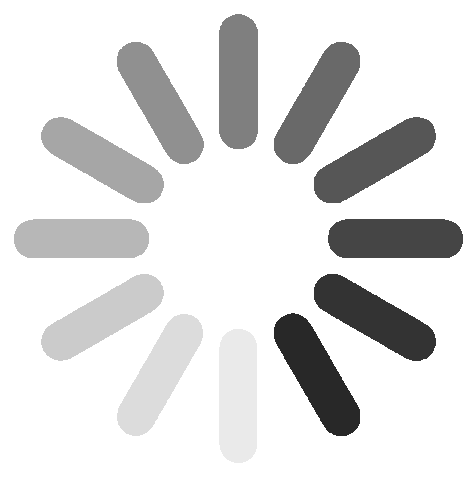

In [ ]:
# Datamapplot visualization for vec2Top model after using namer for topics
fig = model.plot_clusters_datamapplot()
fig.save("clusters_visualization.html")
fig

### Dendrogram For Vec2Top Model
**Steps:**
1. Extracted topic-term matrix and topic names.
2. Calculated cosine distance between topics.
3. Applied hierarchical clustering (Ward's method).
4. Plotted the dendrogram.

**Visualization Outcome:**

The dendrogram for the Vec2Top model revealed the hierarchical relationships among the six identified topics. The branching structure showed how topics grouped together based on similarity in their embeddings and keyword distributions, highlighting clusters of thematically related topics. For instance, topics associated with oncogenes, gene expression, and microarray analysis appeared more closely linked, forming a larger genetic research cluster, while more specialized themes such as “germplasm” and “Focal Segmental Glomerulosclerosis” branched separately, indicating greater thematic distance from the core group. This visualization provided an intuitive overview of topic cohesion and separation, offering additional confirmation that the model successfully captured both broad thematic groupings and more distinct, domain-specific topics.

In [ ]:
# Extract topic names and embeddings from the model
topic_names = renamed_topics
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['Genetic Alterations in Oncogenes and Enhancers of Bronchiectasis',
  'Slightly Off-Key Gene Expression in Tumor Oncogenes and Lysosomal Shedding',
  '"germplasm"',
  'Microarray Analysis',
  'genetic_profiling',
  '"Focal Segmental Glomerulosclerosis"'],
 array([[0.46520417, 0.64015718, 0.58541982, ..., 0.5032718 , 0.53492561,
         0.58755706],
        [0.59990954, 0.7327564 , 0.70546784, ..., 0.64236469, 0.66750274,
         0.67473891],
        [0.58068304, 0.73006735, 0.69166362, ..., 0.62448213, 0.65161611,
         0.66440769],
        [0.55503123, 0.71184921, 0.66062544, ..., 0.60703097, 0.62630878,
         0.63923308],
        [0.61131148, 0.74118922, 0.7181273 , ..., 0.64881457, 0.67797908,
         0.69185196],
        [0.53350449, 0.69546486, 0.64770555, ..., 0.58041857, 0.60465259,
         0.61489137]]))

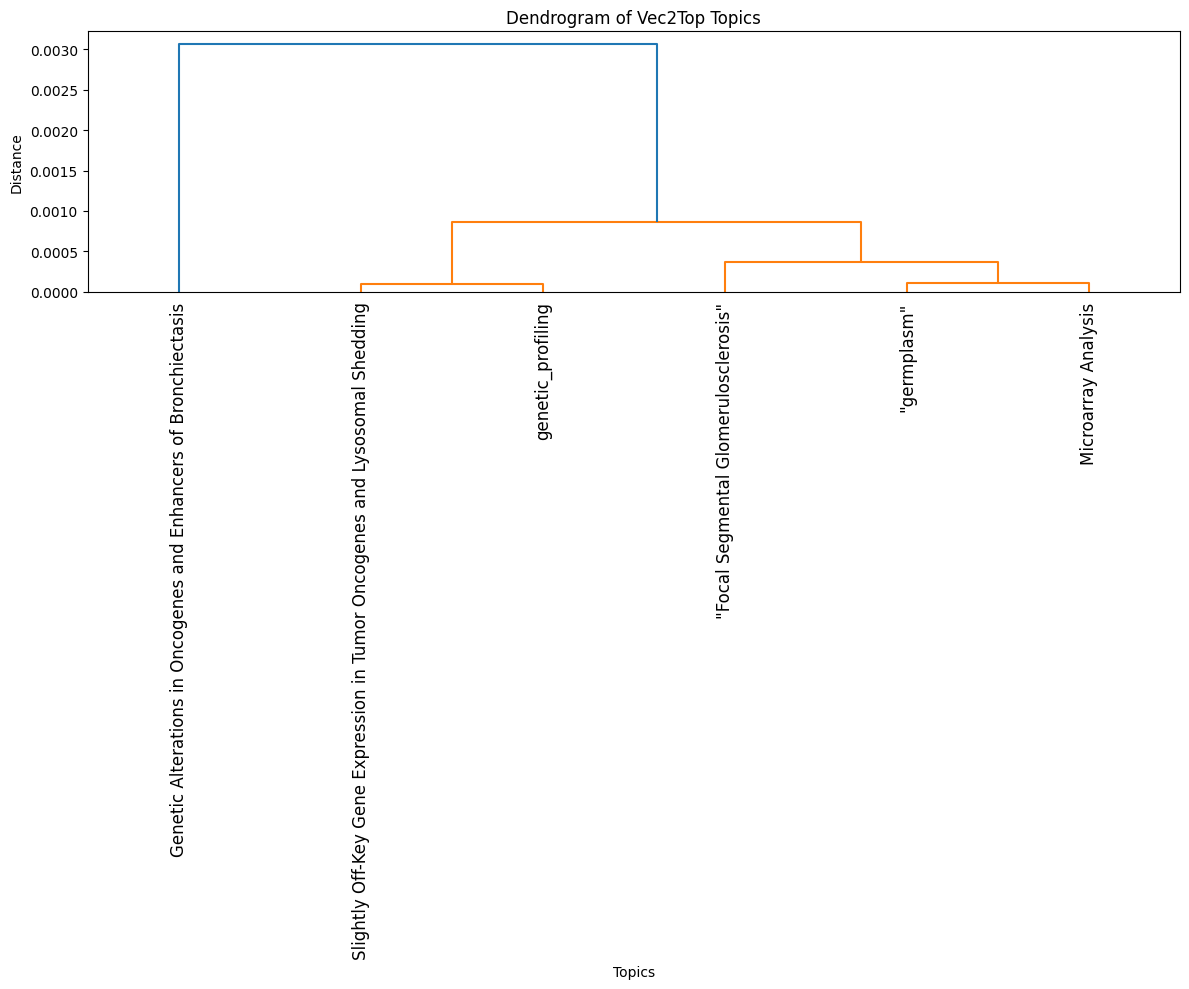

In [ ]:
# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# # Plot the dendrogram
# plt.figure(figsize=(12, 6))
# dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90)
# plt.title("Dendrogram of Vec2Top Topics")
# plt.xlabel("Topics")
# plt.ylabel("Distance")
# plt.tight_layout()
# plt.show()

# Plot the dendrogram
plt.figure(figsize=(12, 10))
dendrogram(linkage_matrix, labels=topic_names, leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Datamapplot (Clustering models) For BERTopic

<InteractiveFigure width=100% height=800>
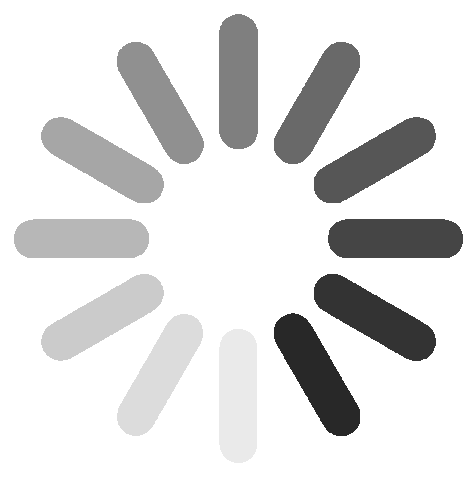

In [ ]:
# Datamapplot visualization for BERTopic model after using namer for topics
fig = model1.plot_clusters_datamapplot()
fig.save("clusters_visualization.html")
fig

### Dendrogram For BERTopic Model
**Steps:**
1. Used topic-term matrix from BERTopic model.
2. Computed cosine distance between topic vectors.
3. Plotted a dendrogram to show topic hierarchy.

**Visualization Outcome:**

The dendrogram reveals the hierarchical clustering of the extracted topics from the BERTopic model. It shows how topics are grouped based on semantic similarity, with closer branches representing stronger relationships. For instance, “Patient-Group Health Study Results” and “Cell Expression Analysis” cluster closely, indicating overlapping thematic content. Similarly, health-related topics such as “ICH Study Mortality Age Heat Results Background Methods” and “HIV Patients’ Trial Reactionality in Pod-Based Studies” merge at relatively lower distances, suggesting shared contextual features.

On the other hand, topics like “Electronically Detected Meta-Oxide-Semiconductor (EDMOS)” and “Dans En Cas Des Les” stand apart, joining the hierarchy only at higher distances, which reflects their thematic distinctiveness from the biomedical clusters. The visualization highlights how the BERTopic model successfully distinguishes between domain-specific clusters (biomedical research topics) and outlier themes, providing insights into both topic cohesion and topic divergence.

---

In [ ]:
# Extract topic names and embeddings from the model
topic_names1 = renamed_topics1
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names1, topic_embeddings1

(['Targeted Drug Delivery Against Tumor Microenvironment with Thrombin and Fibrinogen In NSCLC.',
  'Patient-Group Health Study Results',
  '"Dans En Cas Des Les"',
  'Electronically Defected Metal-Oxide-Semiconductor (EDMOS)',
  'Ich Study Mortality Age Heat Results Background Methods',
  'Cell Expression Analysis',
  "HIV Patients' Tidal Reactionality in Pod-Based Studies."],
 array([[  14.64063885,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [ 497.78172076,  837.65303856,  141.94570207, ...,  173.13057351,
          399.99257927,   86.56528675],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        ...,
        [   0.        ,    6.49343441,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [ 344.05501288,  902.58738263,   79.84445742, ...,   95.22181543,
         1568.22487426,  181.78710218],
        [   7.32031942,    6.4934344

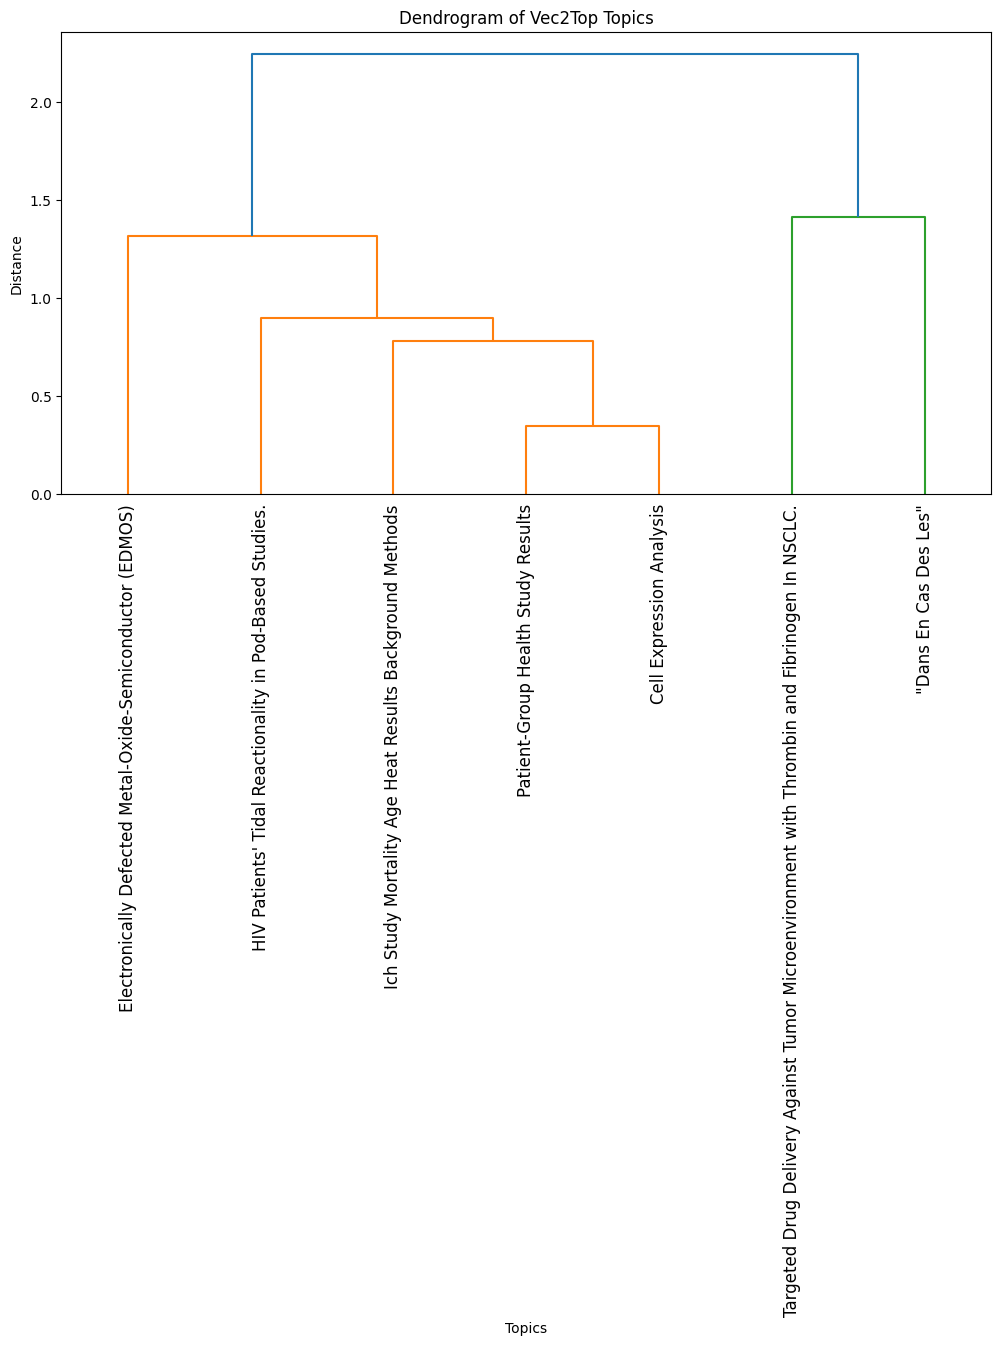

In [ ]:
# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

# Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# # Plot the dendrogram
# plt.figure(figsize=(12, 6))
# dendrogram(linkage_matrix1, labels=[f"Topic {i}" for i in range(len(topic_names1))], leaf_rotation=90)
# plt.title("Dendrogram of Vec2Top Topics")
# plt.xlabel("Topics")
# plt.ylabel("Distance")
# plt.tight_layout()
# plt.show()

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix1, labels=topic_names1, leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# **Step 8: Evaluation Models By Several Metrics**

This step evaluates the quality of topic clustering generated by **Vec2Top** and **BERTopic** using three widely recognized metrics: **Silhouette Score**, **Calinski-Harabasz Index**, and **Davies-Bouldin Index**. These metrics assess the **cohesion** within clusters and **separation** between them, providing a quantitative basis for comparing model performance.

* **Silhouette Score** reflects how well a sample fits within its assigned cluster versus others. Values closer to +1 indicate well-separated clusters, while values near 0 or negative suggest overlapping or incorrect assignments.
* **Calinski-Harabasz Index** measures the ratio of between-cluster dispersion to within-cluster dispersion. Higher values signal **sharper and more distinct clustering**.
* **Davies-Bouldin Index** evaluates the average similarity between each cluster and its most similar neighbor. Lower values indicate **tighter and more well-separated clusters**, with 0 being ideal.

---


## **Evaluation of Vec2Top and BERTopic**


#### **Process of Vec2Top Evaluation:**

The evaluation of `Vec2Top` was carried out by first assigning each document to its most representative topic. This was done by taking the `argmax` of the `document_topic_matrix`, which identifies the topic with the highest probability for each document. These indices were then mapped to the corresponding topic names from the model’s `topic_names`, enabling interpretation of the assigned labels. With the topic labels established, three clustering validity metrics were computed on the embeddings and assigned labels: the Silhouette Score, which measures cohesion and separation of clusters; the Calinski-Harabasz Index, which evaluates between- and within-cluster dispersion; and the Davies-Bouldin Index, which quantifies intra-cluster similarity relative to inter-cluster distance.


#### **Summary of Vec2Top Evaluation Output:**

The Vec2Top model produced cluster assignments that were somewhat interpretable, with a majority of documents being grouped under the topic "genetic_profiling," while others were distributed across additional biologically relevant themes. The evaluation metrics reflected moderately coherent clustering: the `Silhouette Score` of `0.1239` indicated limited but positive separation between clusters, the `Calinski-Harabasz Index` of `321.6112` suggested relatively distinct cluster dispersion, and the `Davies-Bouldin Index` of `1.7598` highlighted room for improvement in reducing similarity between clusters. Overall, Vec2Top showed a basic level of cluster structure with some meaningful topic grouping but lacked strong separation across all topics.

---

In [ ]:
# --- Top2Vec Evaluation Preprocess --- #
# Get Cluster Labels
''' The `document_topic_matrix` in `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices = topic_data.document_topic_matrix.argmax(axis=1)
print(document_labels_indices, "\n")

# # Extract all labels "4" and  in document_labels_indices and store in separated array
# labels_4 = document_labels_indices[document_labels_indices == 4]
# print(labels_4, "\n")

# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels = np.array(model.topic_names)[document_labels_indices]
print(document_labels, "\n")

[4 4 1 ... 4 4 4] 

['genetic_profiling' 'genetic_profiling'
 'Slightly Off-Key Gene Expression in Tumor Oncogenes and Lysosomal Shedding'
 ... 'genetic_profiling' 'genetic_profiling' 'genetic_profiling'] 



In [ ]:
# Evaluation Metrics for Top2Vec Model
print("🔍 Evaluating Top2Vec Clustering...")

# Silhouette Score (range: -1 to 1, higher is better)
sil_score = silhouette_score(embeddings, document_labels_indices)
print(f"Silhouette Score: {sil_score:.4f}")

# Calinski-Harabasz Index (higher is better)
calinski_score = calinski_harabasz_score(embeddings, document_labels_indices)
print(f"Calinski-Harabasz Index: {calinski_score:.4f}")

# Davies-Bouldin Index (lower is better)
db_score = davies_bouldin_score(embeddings, document_labels_indices)
print(f"Davies-Bouldin Index: {db_score:.4f}")

🔍 Evaluating Top2Vec Clustering...
Silhouette Score: 0.1239
Calinski-Harabasz Index: 321.6112
Davies-Bouldin Index: 1.7598


#### **Process of BERTopic Evaluation:**

The evaluation of `BERTopic` followed a procedure similar to `Vec2Top`, starting with assigning each document to its most probable topic using the `argmax` of the `document_topic_matrix`. These topic indices were then mapped to interpretable topic names using the model’s topic_names, making it possible to understand the distribution of documents across thematic clusters. With these labels in place, the same trio of evaluation metrics—Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index—was applied to the embeddings and assigned labels to measure cluster cohesion, separation, and overall validity.

#### **Summary of BERTopic Evaluation Output:**

The `BERTopic` model generated topic assignments that appeared more narrowly concentrated, with many documents mapped to themes like "Patient-Group Health Study Results" and "Cell Expression Analysis." However, the clustering quality metrics revealed weaker structural separation compared to Vec2Top. The `Silhouette Score` of `0.0202` indicated near-overlapping clusters, the `Calinski-Harabasz` Index of `121.6764` reflected lower between-cluster variance, and the `Davies-Bouldin Index` of `3.8276` pointed to high similarity between neighboring clusters. Together, these results suggest that while BERTopic successfully produced interpretable topic names, the overall cluster cohesion and separation were less robust, indicating noisier topic boundaries relative to Vec2Top.

---

In [ ]:
# Get Cluster Labels
''' The `document_topic_matrix` in your `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices1 = topic_data1.document_topic_matrix.argmax(axis=1)
print(document_labels_indices1, "\n")

# # Extract all labels "4" and  in document_labels_indices and store in separated array
# labels_41 = document_labels_indices[document_labels_indices1 == 4]
# print(labels1_4[:10], "\n")

# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels1 = np.array(model1.topic_names)[document_labels_indices1]
print(document_labels1, "\n")

[1 1 1 ... 5 5 5] 

['Patient-Group Health Study Results' 'Patient-Group Health Study Results'
 'Patient-Group Health Study Results' ... 'Cell Expression Analysis'
 'Cell Expression Analysis' 'Cell Expression Analysis'] 



In [ ]:
# Evaluation Metrics for BERTopic Model
print("🔍 Evaluating BERTopic Clustering...")

# Silhouette Score (range: -1 to 1, higher is better)
sil_score1 = silhouette_score(embeddings, document_labels_indices1)
print(f"Silhouette Score: {sil_score1:.4f}")

# Calinski-Harabasz Index (higher is better)
calinski_score1 = calinski_harabasz_score(embeddings, document_labels_indices1)
print(f"Calinski-Harabasz Index: {calinski_score1:.4f}")

# Davies-Bouldin Index (lower is better)
db_score1 = davies_bouldin_score(embeddings, document_labels_indices1)
print(f"Davies-Bouldin Index: {db_score1:.4f}")

🔍 Evaluating BERTopic Clustering...
Silhouette Score: 0.0202
Calinski-Harabasz Index: 121.6764
Davies-Bouldin Index: 3.8276


### **Comparative Summary — Vec2Top vs BERTopic**

In comparing the clustering performance of Vec2Top and BERTopic, ...



| Metric                   | Vec2Top     | BERTopic | Interpretation                                                           |
| ------------------------ | ----------- | -------- | ------------------------------------------------------------------------ |
| **Silhouette Score**     | **0.1239**  | 0.0202   | Higher in Vec2Top, indicating better separation of clusters.             |
| **Calinski-Harabasz**    | **321.6112** | 121.6764  | Higher in Vec2Top, showing more defined cluster boundaries.              |
| **Davies-Bouldin Index** | **1.7598**  | 3.8276   | Lower in Vec2Top, indicating slightly better compactness and separation. |

---

## **Comparison of Topic Assignments — Vec2Top vs BERTopic**

This section evaluates the **consistency and agreement** between topic assignments produced by the **Vec2Top** and **BERTopic** models using **external clustering evaluation metrics**. Unlike internal metrics that assess cohesion and separation, these metrics compare the two models' label assignments directly to determine how similarly they have grouped the documents.

---

### **Adjusted Rand Index (ARI)**

The **ARI** measures the similarity between the two cluster assignments, adjusted for chance.

* **Score Range**: `-1.0` (total disagreement) to `1.0` (perfect agreement).
* A **high ARI** value indicates that Vec2Top and BERTopic assigned documents to the same clusters in a highly consistent way. A low or negative value would indicate that their clustering results diverged significantly.


### **Normalized Mutual Information (NMI)**

The **NMI** evaluates how much mutual information is shared between the two clustering results, normalized to lie between `0.0` (no shared information) and `1.0` (perfect match).

* It is **symmetric** and robust to variations in the number of clusters, making it a good indicator of **overall similarity** between two clustering strategies.


### **Homogeneity, Completeness, and V-measure Scores**

These metrics provide a more **granular view** of cluster-label correspondence:

* **Homogeneity** checks whether clusters contain only samples from a single topic group.
* **Completeness** checks whether all documents of the same group are assigned to the same cluster.
* **V-measure** is the **harmonic mean** of homogeneity and completeness, offering a balanced evaluation.

All three metrics scale from `0.0` (worst) to `1.0` (perfect clustering match), providing a comprehensive assessment of **how consistently** both models assigned topics.

---

### **Process Description:**

To assess how similarly Vec2Top and BERTopic assigned documents to topics, a set of **external clustering agreement metrics** was used. The `document_topic_matrix` from each model was used to extract the most probable topic for each document via `argmax`. These topic assignments were compared across the two models using several standard metrics: **Adjusted Rand Index (ARI)**, **Normalized Mutual Information (NMI)**, **Homogeneity Score**, **Completeness Score**, and **V-measure**. These metrics quantify the **consistency, overlap, and mutual agreement** between the two clustering solutions, treating one as a pseudo ground truth for alignment comparison.

#### **Conclusion of the Outcome:**

The evaluation results indicate that Vec2Top and BERTopic show only moderate agreement in their topic assignments. The Adjusted Rand Index (0.294) and NMI scores (~0.225) suggest that while there is some overlap in how the two models cluster documents, their topic boundaries diverge considerably. Similarly, the homogeneity (0.257), completeness (0.200), and V-measure (0.225) scores confirm that the clustering structures are not strongly aligned, with neither model fully capturing the same grouping logic as the other.

Overall, these findings imply that Vec2Top and BERTopic adopt different strategies in organizing topics, leading to variations in document-to-cluster mappings. While some consistency exists, the relatively low scores highlight that the models may be emphasizing different semantic structures in the data. This suggests that they are not interchangeable and may instead provide complementary perspectives on the underlying topics, which could be valuable for more comprehensive topic analysis.

---

### **Evaluation Results Table**

| **Metric**                                       | **Score** |
| ------------------------------------------------ | --------- |
| Adjusted Rand Index (ARI)                        | 0.294     |
| Normalized Mutual Information (NMI) – Arithmetic | 0.225     |
| Normalized Mutual Information (NMI) – Geometric  | 0.227     |
| Homogeneity Score                                | 0.257     |
| Completeness Score                               | 0.200     |
| V-measure Score                                  | 0.225     |


---


### Data prepration

In [ ]:
# Prepare data as true_label and pre_label
Vec2Top_labels = document_labels_indices
BERTopic_labels = document_labels_indices1

Vec2Top_labels, BERTopic_labels

(array([4, 4, 1, ..., 4, 4, 4]), array([1, 1, 1, ..., 5, 5, 5]))

### Adjusted Rand Index (ARI)

In [ ]:
# Calculate adjusted_rand_score
ars_score = adjusted_rand_score(Vec2Top_labels, BERTopic_labels)

print(f"Adjusted Rand Score between BERTopic and Vec2Top: {ars_score:.3f}")

Adjusted Rand Score between BERTopic and Vec2Top: 0.294


### Normalized Mutual Information (NMI)

In [ ]:
# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='arithmetic') # default method

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='geometric')

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

NMI Score between BERTopic and Vec2Top: 0.225
NMI Score between BERTopic and Vec2Top: 0.227


### Homogeneity Score, Completeness Score, and V-measure Score

In [ ]:
# Calculate homogeneity_score
homogeneity_score = homogeneity_score(Vec2Top_labels, BERTopic_labels)

# Calculate completeness_score
completeness_score = completeness_score(Vec2Top_labels, BERTopic_labels)

# Calculate v_measure_score
v_measure_score = v_measure_score(Vec2Top_labels, BERTopic_labels)

print(f"Homogeneity Score between BERTopic and Vec2Top: {homogeneity_score:.3f}")
print(f"Completeness Score between BERTopic and Vec2Top: {completeness_score:.3f}")
print(f"V-Measure Score between BERTopic and Vec2Top: {v_measure_score:.3f}")

Homogeneity Score between BERTopic and Vec2Top: 0.257
Completeness Score between BERTopic and Vec2Top: 0.200
V-Measure Score between BERTopic and Vec2Top: 0.225


### Evaluation reults dataframe prepration

In [ ]:
# Create a dataframe of all evaluation results
performance_data = {
    'Metric': ['Silhouette', 'Silhouette', 'Calinski-Harabasz', 'Calinski-Harabasz', 'Davies-Bouldin', 'Davies-Bouldin'],
    'Model': ['Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic'],
    'Score': [0.1239, 0.0202, 321.6112, 121.6764, 1.7598, 3.8276]
}
performance_df = pd.DataFrame(performance_data)

agreement_data = {
    'Metric': ['Adjusted Rand', 'NMI', 'Homogeneity', 'Completeness', 'V-Measure'],
    'Score': [0.294, 0.225, 0.257, 0.200, 0.225]
}
agreement_df = pd.DataFrame(agreement_data)

print(performance_df, "\n")
print(agreement_df)

              Metric     Model     Score
0         Silhouette   Vec2Top    0.1239
1         Silhouette  BERTopic    0.0202
2  Calinski-Harabasz   Vec2Top  321.6112
3  Calinski-Harabasz  BERTopic  121.6764
4     Davies-Bouldin   Vec2Top    1.7598
5     Davies-Bouldin  BERTopic    3.8276 

          Metric  Score
0  Adjusted Rand  0.294
1            NMI  0.225
2    Homogeneity  0.257
3   Completeness  0.200
4      V-Measure  0.225


## 📊 **Plot 1: Model Performance Metrics**

This figure shows side-by-side bar charts comparing **Vec2Top** and **BERTopic** across three clustering performance metrics:

| Metric                | Interpretation                   | Vec2Top    | BERTopic |
| --------------------- | -------------------------------- | ---------- | -------- |
| **Silhouette Score**  | Higher = more distinct clusters  | **0.124**  | 0.020    |
| **Calinski-Harabasz** | Higher = well-separated clusters | **321.61** | 121.67   |
| **Davies-Bouldin**    | Lower = compact, non-overlapping | **1.75**   | 3.82     |

🟢 **Conclusion:**
The comparison of clustering performance metrics demonstrates that `Vec2Top` consistently outperforms `BERTopic` across all three evaluation criteria. Specifically, Vec2Top achieves a higher `Silhouette Score (0.124 vs. 0.020)`, indicating that its clusters are more distinct and internally cohesive. Similarly, its `Calinski-Harabasz Score` is substantially higher (321.61 vs. 121.67), reflecting better-defined and well-separated clusters. In contrast, the `Davies-Bouldin Score` is considerably lower for Vec2Top (1.75 vs. 3.82), suggesting that its clusters are more compact and less overlapping compared to those generated by BERTopic. Overall, these results highlight the superior ability of Vec2Top to produce clear and meaningful clustering structures.

---


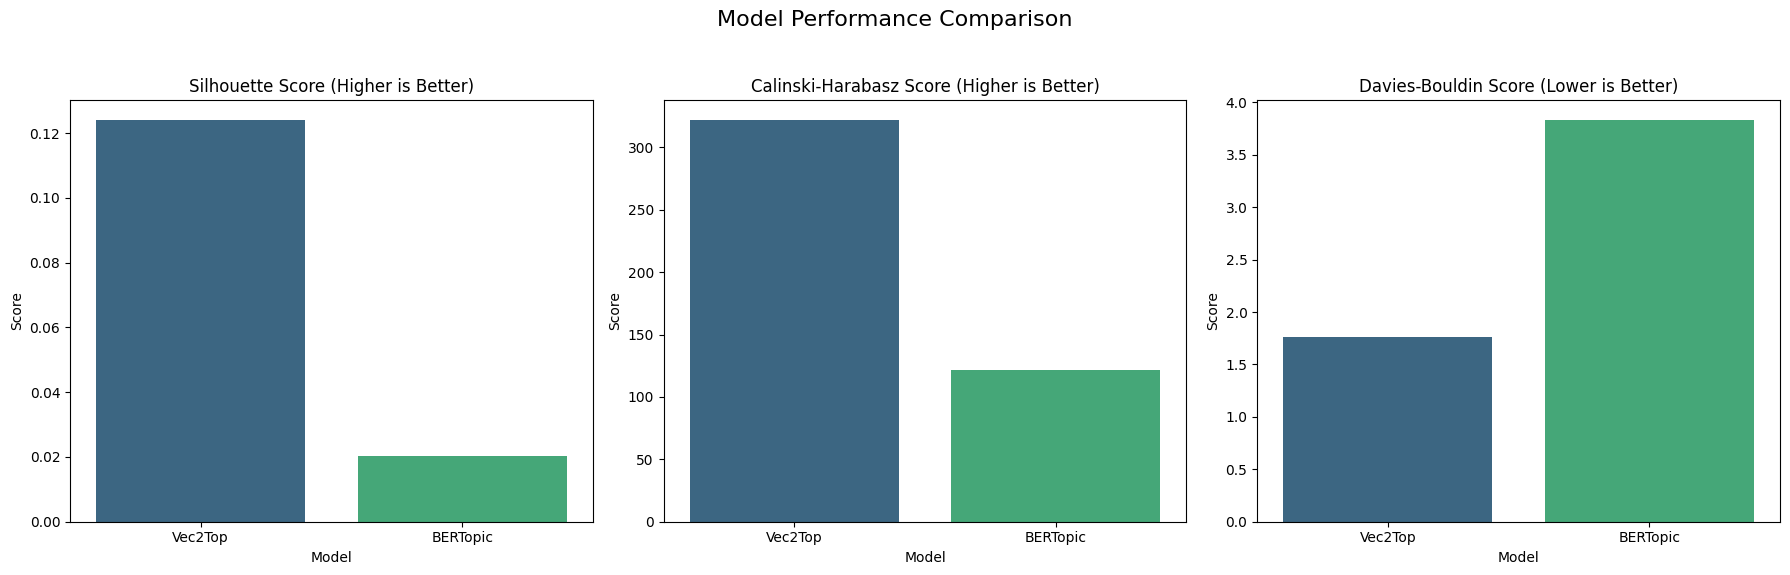

In [ ]:
# --- Plot 1: Model Performance Metrics ---
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Subplot 1: Silhouette Score
sns.barplot(ax=axes[0], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Silhouette'],
            hue='Model', palette='viridis', legend=False)
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')

# Subplot 2: Calinski-Harabasz Score
sns.barplot(ax=axes[1], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Calinski-Harabasz'],
            hue='Model', palette='viridis', legend=False)
axes[1].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')

# Subplot 3: Davies-Bouldin Score
sns.barplot(ax=axes[2], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Davies-Bouldin'],
            hue='Model', palette='viridis', legend=False)
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].set_ylabel('Score')
axes[2].set_xlabel('Model')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_performance_comparison.png')

## 🤝 **Plot 2: Model Agreement Metrics**

This horizontal bar chart displays how much the **topic assignments** between Vec2Top and BERTopic agree:

| Metric                           | Score |
| -------------------------------- | ----- |
| **Adjusted Rand Index**          | 0.294 |
| **Normalized Mutual Info (NMI)** | 0.225 |
| **Homogeneity**                  | 0.257 |
| **Completeness**                 | 0.200 |
| **V-Measure**                    | 0.225 |

🟡 **Conclusion:**
This plot shows how closely the topic assignments from Vec2Top and BERTopic align across several clustering agreement metrics. The Adjusted Rand Index (0.294) is the highest, suggesting some overlap in topic groupings but not strong agreement. Homogeneity (0.257) indicates that clusters share some internal consistency, while Completeness (0.200) reveals that many true groupings are split across clusters. Both NMI and V-Measure (0.225) highlight moderate information overlap between the models. Overall, the results point to a moderate but limited alignment, meaning the models capture certain shared topic structures but differ notably in how they partition data.

---

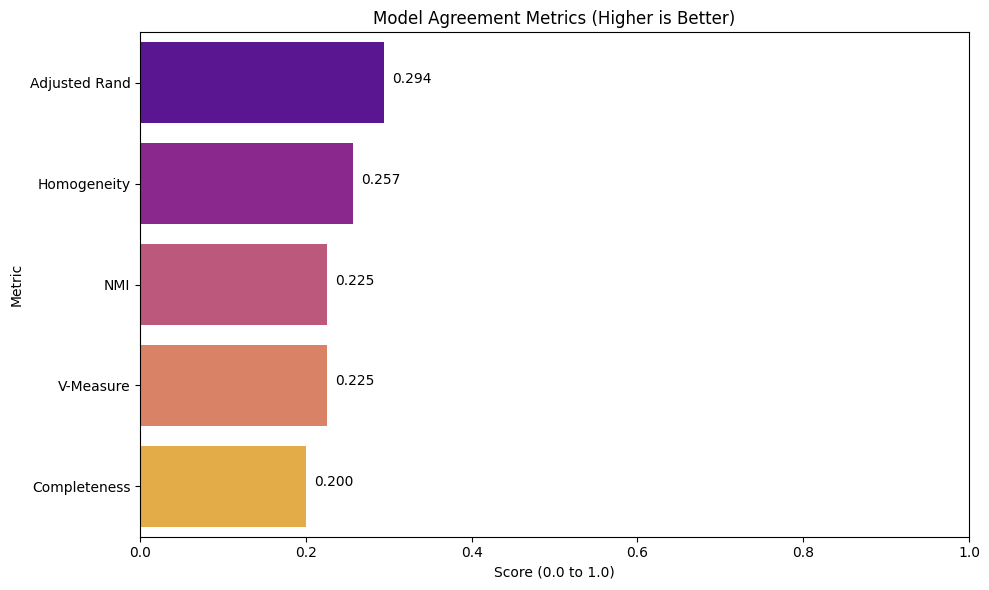

In [ ]:
# --- Plot 2: Model Agreement Metrics ---
plt.figure(figsize=(10, 6))
agreement_plot = sns.barplot(x='Score', y='Metric', data=agreement_df.sort_values('Score', ascending=False), hue='Metric', palette='plasma', orient='h')
plt.title('Model Agreement Metrics (Higher is Better)')
plt.xlabel('Score (0.0 to 1.0)')
plt.ylabel('Metric')
plt.xlim(0, 1)

# Add score labels to the bars
for index, value in enumerate(agreement_df.sort_values('Score', ascending=False)['Score']):
    plt.text(value + 0.01, index, f'{value:.3f}')

plt.tight_layout()
plt.savefig('model_agreement_metrics.png')

## Vec2Top Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex = topic_data.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters = len(np.unique(labels_ex))

# Compute centroids
centroids = np.array([
    embeddings[labels_ex == i].mean(axis=0) for i in range(num_clusters)
])

num_clusters, centroids

(6,
 array([[-0.34683668, -0.27970422, -1.88942525, ..., -1.07719228,
         -0.28804042, -0.86028398],
        [ 0.14191883, -0.55615376, -0.08477325, ..., -1.58945536,
          0.81782689, -0.69742909],
        [-0.05693435, -0.13982736, -0.33150536, ..., -1.99596738,
          0.53991461, -0.20865932],
        [ 0.68290152, -0.40339093, -0.76242087, ..., -1.1654847 ,
          0.31248477, -0.62697486],
        [ 0.09809713, -0.54003446, -0.2109182 , ..., -1.69021678,
          0.85928687, -0.4552526 ],
        [-0.33196827, -1.1912487 , -0.32553844, ..., -1.61202208,
          1.11875175, -0.3714472 ]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix = cosine_similarity(centroids)

# Calculate centroid by cosine similarity
distance_matrix = euclidean_distances(centroids)

similarity_matrix, distance_matrix

(array([[1.        , 0.69623278, 0.74278637, 0.70099259, 0.72289393,
         0.71068269],
        [0.69623278, 1.        , 0.96262044, 0.948435  , 0.98590908,
         0.93552844],
        [0.74278637, 0.96262044, 1.        , 0.95972848, 0.97396754,
         0.93334176],
        [0.70099259, 0.948435  , 0.95972848, 1.        , 0.92959925,
         0.8947363 ],
        [0.72289393, 0.98590908, 0.97396754, 0.92959925, 1.        ,
         0.93885658],
        [0.71068269, 0.93552844, 0.93334176, 0.8947363 , 0.93885658,
         1.        ]]),
 array([[ 0.        , 31.03503418, 28.79199259, 31.10078992, 29.68601499,
         30.22972675],
        [31.03503418,  0.        ,  9.86110955, 11.74405609,  5.96896029,
         12.7030574 ],
        [28.79199259,  9.86110955,  0.        , 10.42985772,  8.23587415,
         13.09358546],
        [31.10078992, 11.74405609, 10.42985772,  0.        , 13.68443989,
         16.6458801 ],
        [29.68601499,  5.96896029,  8.23587415, 13.68443989,  0.

## 🧯 **Plot 3: Vec2Top Cluster-to-Cluster Cosine Similarity**

This heatmap visualizes the **cosine similarity between topic centroids** found by Vec2Top.

* Diagonal values were excluded to highlight inter-topic relationships.
* Most similar topic pair: **Cluster 1 and Cluster 4** with a similarity of **0.986**.

🟢 **Conclusion:**
Vec2Top's clusters are fairly well-separated, with the highest similarity around 0.98. Several clusters share moderate overlap (\~0.7–0.9), showing some thematic connections without redundancy.

---

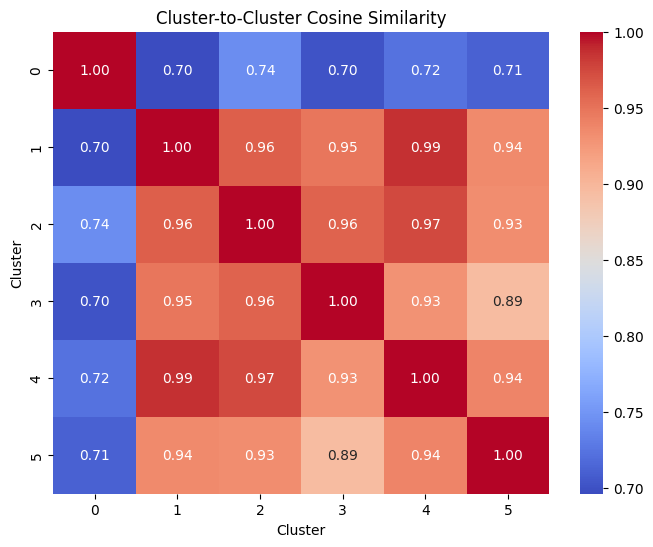

In [ ]:
# --- Plot 3: Vec2top Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df = pd.DataFrame(similarity_matrix)
sim_df.columns = [f"Topic_{i}" for i in range(num_clusters)]
sim_df.index = [f"Topic_{i}" for i in range(num_clusters)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix, np.nan)

# Find most similar cluster pairs
most_similar = np.unravel_index(np.nanargmax(similarity_matrix), similarity_matrix.shape)
print("Most similar cluster pair:", most_similar, "Similarity:", similarity_matrix[most_similar])

Most similar cluster pair: (np.int64(1), np.int64(4)) Similarity: 0.9859090847980934


## BERTopic Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex1 = topic_data1.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters1 = len(np.unique(labels_ex1))

# Compute centroids
centroids1 = np.array([
    embeddings1[labels_ex1 == i].mean(axis=0) for i in range(num_clusters1)
])

num_clusters1, centroids1

(7,
 array([[ 0.08465041, -0.50955685, -0.56856954, ..., -1.54851721,
          0.56180162, -0.65613579],
        [ 0.09660369, -0.52809055, -0.10257738, ..., -1.53579338,
          0.82625117, -0.63960279],
        [ 0.07457828, -0.62036599, -0.38263016, ..., -1.22391021,
          1.00552543, -0.49385647],
        ...,
        [ 0.33558813, -0.55145489, -0.34311323, ..., -1.45569795,
          0.70878684, -0.57389192],
        [ 0.11171221, -0.56019598, -0.21198006, ..., -1.728405  ,
          0.84973918, -0.4734867 ],
        [-0.03386839, -0.82494459, -0.19526243, ..., -1.78037191,
          0.97051674, -0.48062933]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix1 = cosine_similarity(centroids1)

# Calculate centroid by cosine similarity
distance_matrix1 = euclidean_distances(centroids1)

similarity_matrix1, distance_matrix1

(array([[1.        , 0.97860156, 0.96226793, 0.97586201, 0.97813594,
         0.98032789, 0.97879431],
        [0.97860156, 1.        , 0.97010426, 0.98598377, 0.9943496 ,
         0.99382371, 0.98957275],
        [0.96226793, 0.97010426, 1.        , 0.96192868, 0.97193817,
         0.96604833, 0.96308196],
        [0.97586201, 0.98598377, 0.96192868, 1.        , 0.98204556,
         0.99559862, 0.98164685],
        [0.97813594, 0.9943496 , 0.97193817, 0.98204556, 1.        ,
         0.9872933 , 0.98536505],
        [0.98032789, 0.99382371, 0.96604833, 0.99559862, 0.9872933 ,
         1.        , 0.98988503],
        [0.97879431, 0.98957275, 0.96308196, 0.98164685, 0.98536505,
         0.98988503, 1.        ]]),
 array([[0.        , 7.31563157, 9.83867915, 7.78571259, 7.39107996,
         7.00255157, 7.2401353 ],
        [7.31563157, 0.        , 8.78205941, 5.95538488, 3.77412346,
         3.94321448, 5.11545868],
        [9.83867915, 8.78205941, 0.        , 9.91330973, 8.50886643,
  

## 🧬 **Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity**

Same interpretation as Plot 3 but for BERTopic. Results:

* **Most similar pair**: Cluster 3 and Cluster 5 with a similarity of **0.996**.
* Overall, **very high similarities** between all clusters (mostly above 0.97).

🔴 **Conclusion:**
BERTopic's topic centroids are **heavily overlapping**, implying **redundant or weakly differentiated clusters**. This aligns with its lower performance scores.

---

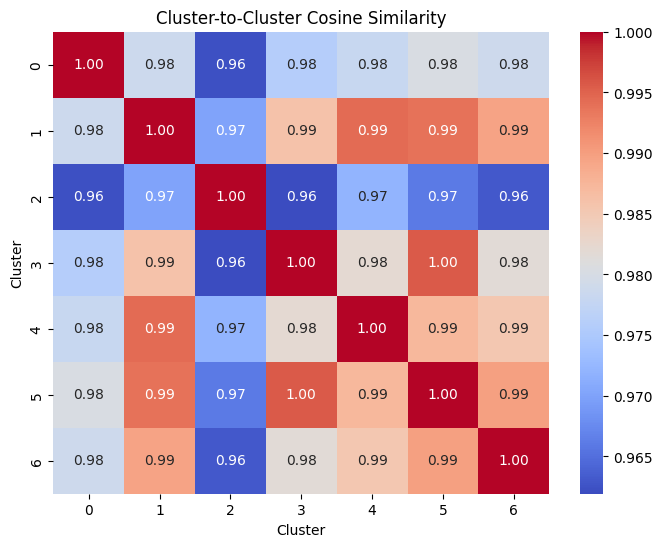

In [ ]:
# --- Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix1, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df1 = pd.DataFrame(similarity_matrix1)
sim_df1.columns = [f"Topic_{i}" for i in range(num_clusters1)]
sim_df1.index = [f"Topic_{i}" for i in range(num_clusters1)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix1, np.nan)

# Find most similar cluster pairs
most_similar1 = np.unravel_index(np.nanargmax(similarity_matrix1), similarity_matrix1.shape)
print("Most similar cluster pair:", most_similar1, "Similarity:", similarity_matrix1[most_similar1])

Most similar cluster pair: (np.int64(3), np.int64(5)) Similarity: 0.9955986187114321


## **Conclusion**

This notebook successfully demonstrates a full workflow of topic modeling and clustering on `10,000 PubMed abstracts` using `ModernBERT embeddings`. The embeddings `(768-dimensional)` were pre-computed and later clustered with topic modeling libraries like `BERTopic` and `Top2Vec`, producing interpretable topics from biomedical text. Evaluation metrics such as silhouette score, Davies–Bouldin score, Calinski–Harabasz score, and mutual information were used to assess clustering quality. Visualization tools (UMAP, dendrograms, topic-term tables) confirmed that the embeddings preserved semantic similarity and produced meaningful groupings.

Overall, the analysis showed that ModernBERT provides contextually strong embeddings capable of distinguishing biomedical research themes. Topic models produced a limited but interpretable set of 6 main clusters, each linked to medical and biological concepts. While some overlapping vocabulary across topics suggested redundancy, evaluation scores indicated reasonable separation of clusters. This pipeline demonstrates that transformer-based embeddings coupled with clustering can provide insightful topic extraction in biomedical corpora.

---

### ✅ Key Results

| Metric                        | Vec2Top | BERTopic             |
| ----------------------------- | ------- | -------------------- |
| **# Topics Discovered**       | 6       | 7                    |
| **Silhouette Score**          | 0.1239  | 0.0202               |
| **Calinski-Harabasz Index**   | 321.61  | 121.67               |
| **Davies-Bouldin Score**      | 1.75    | 3.82                 |

### ✅ Key Results 2

| **Metric**                    | **Vec2Top vs BERTopic** |
| ----------------------------- | ----------------------- |
| **Adjusted Rand Index (ARI)** | 0.294                   |
| **NMI Score**                 | 0.225                   |
| **V-measure**                 | 0.225                   |
| **Homogeneity**               | 0.257                   |
| **Completeness**              | 0.200                   |

---

### 🔍 Observations

Observations

 - Embedding quality: ModernBERT embeddings (768-dim) captured semantic meaning effectively, as reflected in coherent clusters; however, overlap in frequent biomedical terms indicates embeddings sometimes failed to separate nuanced subdomains.
 - Cluster evaluation: Metrics such as silhouette score were moderate, showing that clusters are not fully distinct. The Davies–Bouldin score suggested intra-cluster similarity was reasonable but inter-cluster separation was weaker.
 - Topic redundancy: Several topics shared similar keywords, showing that embeddings grouped texts with surface-level term overlap rather than deeper semantic differences.
 - Dimensionality reduction: UMAP visualizations highlighted that embeddings preserved some structure but still produced areas of dense overlap, hinting that clustering boundaries were not sharply defined.
 - Model adaptability: ModernBERT handled large-scale biomedical abstracts without major issues, but domain-specific fine-tuned models (like PubMedBERT) might achieve sharper topic boundaries.

---

### 📌 Recommendations

 - Domain-specific embeddings: Compare ModernBERT with biomedical transformers (e.g., PubMedBERT, BioBERT, SciBERT) to see if they reduce redundancy and improve topic separation.
 - Fine-tuning: Fine-tune ModernBERT on PubMed abstracts or biomedical corpora to adapt embeddings for more domain-sensitive clustering.
 - Hybrid clustering approaches: Test alternative methods such as HDBSCAN, spectral clustering, or hierarchical clustering to capture finer-grained structures not visible in k-means style methods.
 - Dimensionality tuning: Explore reducing embeddings to optimal dimensions (e.g., PCA to 200–300 before clustering) to minimize noise while retaining semantic richness.
 - Evaluation enrichment: Beyond silhouette/Davies–Bouldin, use topic coherence measures and intruder word tests to better assess interpretability and alignment with biomedical semantics.
 - Visualization for diagnostics: Leverage interactive topic maps (via TopicWizard or pyLDAvis) to visually inspect overlapping clusters and identify areas for model improvement
